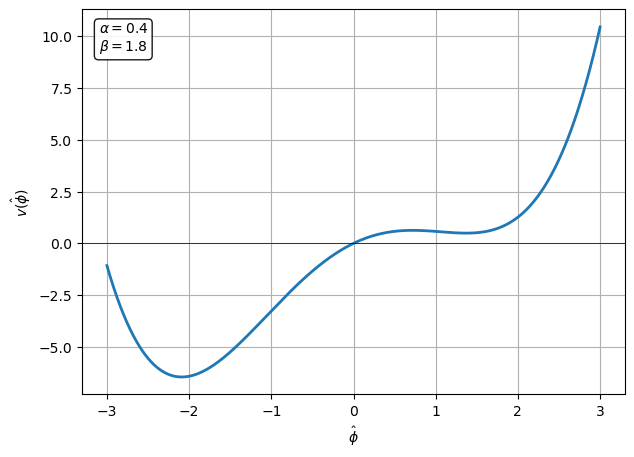


 n |   E_n (rescaled)   |   Lambda_n / H
---------------------------------------------
0 |  7.342320e-04 |  1.859831e-05
1 |  6.010609e-01 |  1.522505e-02
2 |  5.351866e+00 |  1.355644e-01
3 |  1.028362e+01 |  2.604871e-01
4 |  1.277263e+01 |  3.235344e-01


In [24]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh

# ----------------------------------------------------------------------
# 1) symbolic definitions
# ----------------------------------------------------------------------
phi, alpha, beta = sp.symbols('phi alpha beta', real=True)
Omega = 1 + alpha + sp.sqrt(beta)

# original potential v(phi)
v = (sp.pi**2 / (3 * Omega)) * (
    4*alpha*phi
    - 2*(beta/Omega)*phi**2
    + (4/Omega**3)*phi**4
)

# effective FP-Schrodinger potential W(phi)
v_prime = sp.diff(v, phi)
v_double_prime = sp.diff(v_prime, phi)
W = sp.Rational(1, 2) * (v_prime**2 - v_double_prime)

v_func = sp.lambdify((phi, alpha, beta), v, 'numpy')
W_func = sp.lambdify((phi, alpha, beta), W, 'numpy')

# ----------------------------------------------------------------------
# 2) parameters
# ----------------------------------------------------------------------
alpha_val = 0.4
beta_val = 1.8
lambda_val = 0.05

Omega_val = 1 + alpha_val + np.sqrt(beta_val)
scale = np.sqrt(lambda_val) * Omega_val**2

# grid
L = 8.0
N = 4001
phi_vals = np.linspace(-3, 3, N)
dphi = phi_vals[1] - phi_vals[0]

# ----------------------------------------------------------------------
# 3) plot original potential v(phi)
# ----------------------------------------------------------------------
# ----------------------------------------------------------------------
# 3) plot original potential v(phi)
# ----------------------------------------------------------------------
v_vals = v_func(phi_vals, alpha_val, beta_val)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(phi_vals, v_vals, lw=2)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel(r'$\hat{\phi}$')
ax.set_ylabel(r'$v\hat{(\phi})$')
#ax.set_title(r'$v(\phi)$')
ax.grid(True)

info_text = (
    rf"$\alpha = {alpha_val}$" "\n"
    rf"$\beta = {beta_val}$"
)

ax.text(
    0.03, 0.97,
    info_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black')
)


plt.show()

# ----------------------------------------------------------------------
# 4) build W(phi) and Hamiltonian
# ----------------------------------------------------------------------
W_vals = W_func(phi_vals, alpha_val, beta_val)

main_diag = np.full(N, -2.0)
off_diag = np.ones(N-1)

laplacian = diags([off_diag, main_diag, off_diag],
                  [-1, 0, 1],
                  format='csr') / dphi**2

T = -0.5 * laplacian
V = diags(W_vals, 0)

H_op = scale * (T + V)

# ----------------------------------------------------------------------
# 5) eigenvalues
# ----------------------------------------------------------------------
num_eigs = 5
E_vals, _ = eigsh(H_op, k=num_eigs, sigma=0.0, which='LM')
E_vals = np.sort(E_vals)

# ----------------------------------------------------------------------
# 6) Lambda_n / H
# ----------------------------------------------------------------------
Lambda_over_H = E_vals / (4 * np.pi**2)

print("\n n |   E_n (rescaled)   |   Lambda_n / H")
print("-"*45)
for n in range(num_eigs):
    print(f"{n:1d} | {E_vals[n]: .6e} | {Lambda_over_H[n]: .6e}")



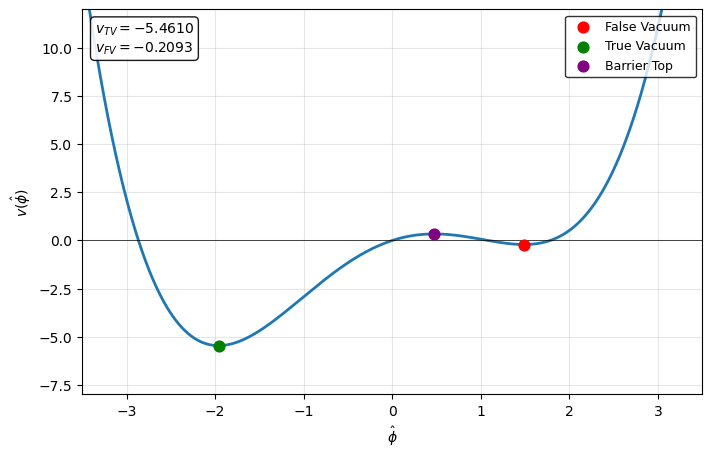


 n |   E_n (rescaled)   |   Lambda_n / H
---------------------------------------------
0 | -6.582807e-05 | -1.667445e-06
1 |  2.608319e-01 |  6.606949e-03
2 |  4.718551e+00 |  1.195223e-01
3 |  9.032383e+00 |  2.287929e-01
4 |  1.139079e+01 |  2.885321e-01


In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
from scipy.signal import find_peaks
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, HPacker, VPacker

# =========================
# ONE SIMPLE TOGGLE
# =========================
SHOW_W = False   # <-- True: show W(phi) inset, False: hide it

# ----------------------------------------------------------------------
# 1) symbolic definitions
# ----------------------------------------------------------------------
phi, alpha, beta = sp.symbols('phi alpha beta', real=True)
Omega = 1 + alpha + sp.sqrt(beta)

v = (sp.pi**2 / (3 * Omega)) * (
    4*alpha*phi
    - 2*(beta/Omega)*phi**2
    + (4/Omega**3)*phi**4
)

v_prime = sp.diff(v, phi)
v_double_prime = sp.diff(v_prime, phi)
W = sp.Rational(1, 2) * (v_prime**2 - v_double_prime)

v_func = sp.lambdify((phi, alpha, beta), v, 'numpy')
W_func = sp.lambdify((phi, alpha, beta), W, 'numpy')

# ----------------------------------------------------------------------
# 2) parameters
# ----------------------------------------------------------------------
alpha_val = 0.3
beta_val = 1.8
lambda_val = 0.05

Omega_val = 1 + alpha_val + np.sqrt(beta_val)
scale = np.sqrt(lambda_val) * Omega_val**2

# grid
N = 4001
L_solve = 8.0
phi_vals = np.linspace(-L_solve, L_solve, N)
dphi = phi_vals[1] - phi_vals[0]

# ----------------------------------------------------------------------
# 3) compute potentials (v always, W only if inset shown)
# ----------------------------------------------------------------------
v_vals = v_func(phi_vals, alpha_val, beta_val)
if SHOW_W:
    W_vals_inset = W_func(phi_vals, alpha_val, beta_val)

# ---- find minima (vacua) in v ----
min_idx, _ = find_peaks(-v_vals)
min_phi = phi_vals[min_idx]
min_v = v_vals[min_idx]

order = np.argsort(min_v)
true_phi, false_phi = min_phi[order[0]], min_phi[order[1]]
true_v, false_v = min_v[order[0]], min_v[order[1]]

# ---- find barrier (max between vacua) in v ----
mask_v = (phi_vals > min(true_phi, false_phi)) & (phi_vals < max(true_phi, false_phi))
barrier_idx, _ = find_peaks(v_vals[mask_v])

bar_phi = phi_vals[mask_v][barrier_idx]
bar_v = v_vals[mask_v][barrier_idx]
imax = np.argmax(bar_v)
bar_phi, bar_v = bar_phi[imax], bar_v[imax]

# ----------------------------------------------------------------------
# 4) main plot: v(phi) + optional inset: W(phi)
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(phi_vals, v_vals, lw=2)
ax.scatter(false_phi, false_v, color='red', s=60, zorder=5, label='False Vacuum')
ax.scatter(true_phi,  true_v,  color='green', s=60, zorder=5, label='True Vacuum')
ax.scatter(bar_phi,   bar_v,   color='purple', s=60, zorder=5, label='Barrier Top')
ax.axhline(0, color='black', lw=0.5)

ax.set_xlabel(r'$\hat{\phi}$')
ax.set_ylabel(r'$v(\hat{\phi})$')

ax.legend(
    loc='upper right',
    frameon=True,
    facecolor='white',
    edgecolor='black',
    fontsize=9
)

info_text = (
    rf"$v_{{TV}} = {true_v:.4f}$" "\n"
    rf"$v_{{FV}} = {false_v:.4f}$"
)

ax.text(
    0.02, 0.97,
    info_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black')
)

# -----------------------------
# OPTIONAL inset: W(phi)
# -----------------------------
if SHOW_W:
    axins = ax.inset_axes([0.48, 0.642, 0.40, 0.35])

    axins.plot(phi_vals, W_vals_inset, lw=1.6)
    axins.axhline(0, color='black', lw=0.4)
    axins.set_facecolor('whitesmoke')
    axins.tick_params(labelsize=8)

    axins.text(
        0.5, 0.95, r"$W(\phi)$",
        transform=axins.transAxes,
        ha='center', va='top',
        fontsize=9, fontweight='bold'
    )

    axins.set_xlim(-5, 5)
    axins.set_ylim(-15, 18)

    min_idx_W, _ = find_peaks(-W_vals_inset)
    if len(min_idx_W) < 2:
        raise RuntimeError("Could not find two minima of W(phi) on this phi range.")

    min_phi_W = phi_vals[min_idx_W]
    min_W = W_vals_inset[min_idx_W]

    orderW = np.argsort(min_W)
    true_phi_W, false_phi_W = min_phi_W[orderW[0]], min_phi_W[orderW[1]]
    true_W, false_W = min_W[orderW[0]], min_W[orderW[1]]

    axins.scatter(true_phi_W,  true_W,  marker='*', s=40, color='black', zorder=6)
    axins.scatter(false_phi_W, false_W, marker='o', s=25, color='black', zorder=6)

    textstr_W = (
        rf"$\star\; W_{{TV}} = {true_W:.3f}$" "\n"
        rf"$\bullet\; W_{{FV}} = {false_W:.3f}$"
    )

    axins.text(
        0.03, 0.96, textstr_W,
        transform=axins.transAxes,
        fontsize=8,
        va='top',
        bbox=dict(boxstyle="square", facecolor="white", alpha=0.9)
    )

    axins.set_xlim(-4, 4)
    axins.set_ylim(-7, 18)

# zoom main v plot
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-8, 12)
ax.grid(True, alpha=0.3)


plt.show()

# ----------------------------------------------------------------------
# 5) build W and solve spectrum (unchanged)
# ----------------------------------------------------------------------
W_vals = W_func(phi_vals, alpha_val, beta_val)

main_diag = np.full(N, -2.0)
off_diag = np.ones(N - 1)

laplacian = diags([off_diag, main_diag, off_diag],
                  [-1, 0, 1],
                  format='csr') / dphi**2

T = -0.5 * laplacian
V = diags(W_vals, 0)

H_op = scale * (T + V)

num_eigs = 5
E_vals, _ = eigsh(H_op, k=num_eigs, sigma=0.0, which='LM')
E_vals = np.sort(E_vals)

Lambda_over_H = E_vals / (4 * np.pi**2)

print("\n n |   E_n (rescaled)   |   Lambda_n / H")
print("-" * 45)
for n in range(num_eigs):
    print(f"{n:1d} | {E_vals[n]: .6e} | {Lambda_over_H[n]: .6e}")

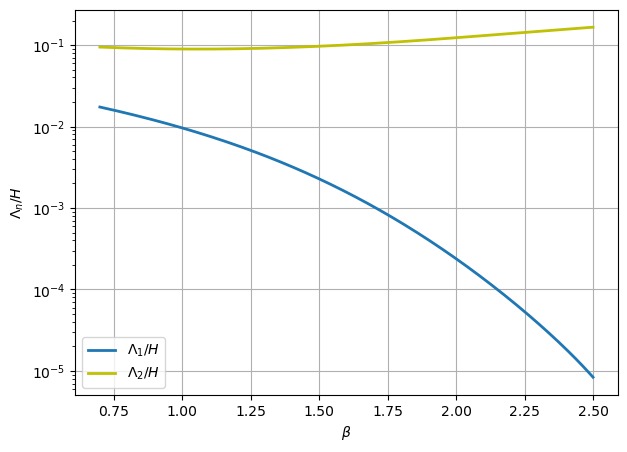

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
from matplotlib.ticker import ScalarFormatter
# --------------------------------------------
# fixed parameters
# --------------------------------------------
alpha_fixed = 0.1
lambda_val = 0.05

# smooth beta range
beta_vals = np.linspace(0.7, 2.5, 200)    # avoid beta=0 exactly (sqrt)

Lambda1 = []
Lambda2 = []

# grid (same as before)
N = 4001
L=8
phi_vals = np.linspace(-L, L, N)
dphi = phi_vals[1] - phi_vals[0]

main_diag = np.full(N, -2.0)
off_diag = np.ones(N-1)
laplacian = diags([off_diag, main_diag, off_diag], [-1,0,1]) / dphi**2
T = -0.5 * laplacian

# --------------------------------------------
# scan over beta
# --------------------------------------------
for beta_val in beta_vals:

    Omega_val = 1 + alpha_fixed + np.sqrt(beta_val)
    scale = np.sqrt(lambda_val) * Omega_val**2

    W_vals = W_func(phi_vals, alpha_fixed, beta_val)
    V = diags(W_vals, 0)

    H_op = scale * (T + V)

    # get lowest few eigenvalues
    E_vals, _ = eigsh(H_op, k=3, sigma=0.0, which='LM')
    E_vals = np.sort(E_vals)

    # convert to Lambda/H
    Lambda1.append(E_vals[1] / (4*np.pi**2))
    Lambda2.append(E_vals[2] / (4*np.pi**2))

# --------------------------------------------
# plot smooth curves
# --------------------------------------------
plt.figure(figsize=(7,5))

plt.plot(beta_vals, Lambda1, lw=2, color='tab:blue', label=r'$\Lambda_1/H$')

plt.plot(
    beta_vals,
    Lambda2,
    lw=2,
    color='y',
    alpha=0.98,          # lighter version of the same color
    label=r'$\Lambda_2/H$'
)

plt.xlabel(r'$\beta$')
plt.ylabel(r'$\Lambda_n/H$')
#plt.title(r'Stochastic spectrum vs $\beta$  ($\alpha=0.1$)')
plt.grid(True)
plt.legend()

plt.yscale('log')

plt.show()



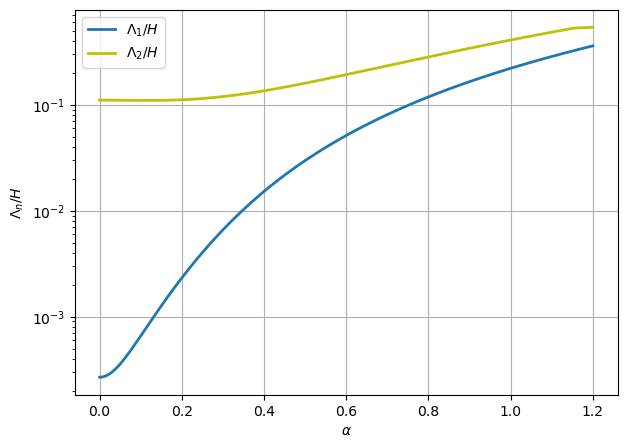

In [5]:
# --------------------------------------------
# fixed parameters
# --------------------------------------------
beta_fixed = 1.8
lambda_val = 0.05

# smooth alpha range
alpha_vals = np.linspace(0.0, 1.2, 200)

Lambda1_alpha = []
Lambda2_alpha = []

# grid (same as before)
N = 4001
L = 8
phi_vals = np.linspace(-L, L, N)
dphi = phi_vals[1] - phi_vals[0]

main_diag = np.full(N, -2.0)
off_diag = np.ones(N-1)
laplacian = diags([off_diag, main_diag, off_diag], [-1,0,1]) / dphi**2
T = -0.5 * laplacian

# --------------------------------------------
# scan over alpha
# --------------------------------------------
for alpha_val in alpha_vals:

    Omega_val = 1 + alpha_val + np.sqrt(beta_fixed)
    scale = np.sqrt(lambda_val) * Omega_val**2

    W_vals = W_func(phi_vals, alpha_val, beta_fixed)
    V = diags(W_vals, 0)

    H_op = scale * (T + V)

    E_vals, _ = eigsh(H_op, k=3, sigma=0.0, which='LM')
    E_vals = np.sort(E_vals)

    Lambda1_alpha.append(E_vals[1] / (4*np.pi**2))
    Lambda2_alpha.append(E_vals[2] / (4*np.pi**2))

# --------------------------------------------
# plot smooth curves
# --------------------------------------------
plt.figure(figsize=(7,5))

plt.plot(alpha_vals, Lambda1_alpha, lw=2, color='tab:blue', label=r'$\Lambda_1/H$')

plt.plot(alpha_vals, Lambda2_alpha, lw=2, color='y',
         alpha=0.98, label=r'$\Lambda_2/H$')

plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\Lambda_n/H$')
#plt.title(r'Stochastic spectrum vs $\alpha$  ($\beta=1$)')
plt.grid(True)
plt.legend()

# optional (highly recommended for decay physics)
plt.yscale('log')
#plt.savefig("decay vs alpha", dpi=300, bbox_inches="tight")
plt.show()


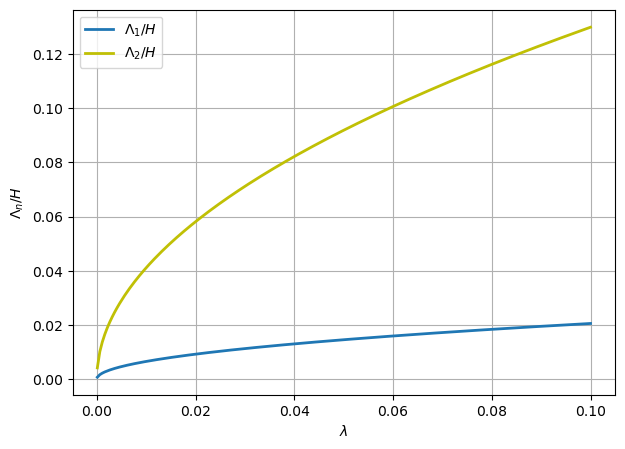

In [6]:
# --------------------------------------------
# fixed parameters
# --------------------------------------------
alpha_fixed = 0.1
beta_fixed = 0.8

# smooth lambda range (avoid exactly zero)
lambda_vals = np.linspace(1e-4,0.1, 200)

Lambda1_lam = []
Lambda2_lam = []

# grid (same as before)
N = 4001
L = 8
phi_vals = np.linspace(-L, L, N)
dphi = phi_vals[1] - phi_vals[0]

main_diag = np.full(N, -2.0)
off_diag = np.ones(N-1)
laplacian = diags([off_diag, main_diag, off_diag], [-1,0,1]) / dphi**2
T = -0.5 * laplacian

# --------------------------------------------
# scan over lambda
# --------------------------------------------
for lambda_val in lambda_vals:

    Omega_val = 1 + alpha_fixed + np.sqrt(beta_fixed)
    scale = np.sqrt(lambda_val) * Omega_val**2

    W_vals = W_func(phi_vals, alpha_fixed, beta_fixed)
    V = diags(W_vals, 0)

    H_op = scale * (T + V)

    E_vals, _ = eigsh(H_op, k=3, sigma=0.0, which='LM')
    E_vals = np.sort(E_vals)

    Lambda1_lam.append(E_vals[1] / (4*np.pi**2))
    Lambda2_lam.append(E_vals[2] / (4*np.pi**2))

# --------------------------------------------
# plot smooth curves
# --------------------------------------------
plt.figure(figsize=(7,5))

plt.plot(lambda_vals, Lambda1_lam, lw=2, color='tab:blue', label=r'$\Lambda_1/H$')

plt.plot(lambda_vals, Lambda2_lam, lw=2, color='y',
         alpha=0.98, label=r'$\Lambda_2/H$')

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\Lambda_n/H$')
#plt.title(r'Stochastic spectrum vs $\lambda$  ($\alpha=0.1,\ \beta=0.8$)')
plt.grid(True)
plt.legend()

# optional but very informative
#plt.yscale('log')

plt.show()
